# Undersampling Strategy Analysis

This notebook analyzes **undersampling** as a strategy to reduce class imbalance bias. Undersampling works by removing samples from the majority class to achieve better class balance.

**Note:** This notebook presents results directly from Guilherme's paper on undersampling and ensemble methods for bias reduction. These are pre-computed results from the research, not newly trained models.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys, os

# Local imports
sys.path.append(os.path.abspath(".."))

from src.paths import DATA_DIR, MODELS_DIR
from src.plot_utils import results_to_dataframe, plot_metrics

/home/phmgc/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Method Scope: Undersampling

The key methods analyzed on the paper here are:

- **baseline**: Baseline without undersampling (control)
- **UBR** (Under-Balanced Random): Random undersampling applied
- **E2SC_US**: Ensemble with ensemble-based undersampling and cluster-based methods

Each method is evaluated on multiple datasets using both RoBERTa (small language model) and Llama3.1 (large language model) as base classifiers.

In [2]:
# Load undersampling results from the paper
results_path = Path('../docs/undersampling_eval_results.json')

with open(results_path) as f:
    results_raw = json.load(f)

print(f"Loaded {len(results_raw)} result entries from {results_path}")

Loaded 4 result entries from ../docs/undersampling_eval_results.json


## Results: Undersampling Performance Across Datasets

In [3]:
df_results = pd.json_normalize(results_raw, record_path='methods', meta='dataset')

df_results = df_results[
	df_results['method'].isin(['baseline', 'UBR', 'E2SC_US']) # Top 3 methods from the paper
][['dataset', 'method', 'macro_f1', 'tpr_gap', 'speedup']]

df_results

,dataset,method,macro_f1,tpr_gap,speedup
0,sentistrength_myspace,baseline,0.810,0.350,1.000
1,sentistrength_myspace,UBR,0.815,0.184,1.577
2,sentistrength_myspace,E2SC_US,0.810,0.215,1.802
6,luxury_beauty,baseline,0.931,0.156,1.000
7,luxury_beauty,UBR,0.920,0.070,1.880
8,luxury_beauty,E2SC_US,0.929,0.091,1.884
12,cds_reviews,baseline,0.920,0.166,1.000
13,cds_reviews,UBR,0.869,0.104,2.026
14,cds_reviews,E2SC_US,0.914,0.124,1.924
15,digital_music,baseline,0.878,0.308,1.000


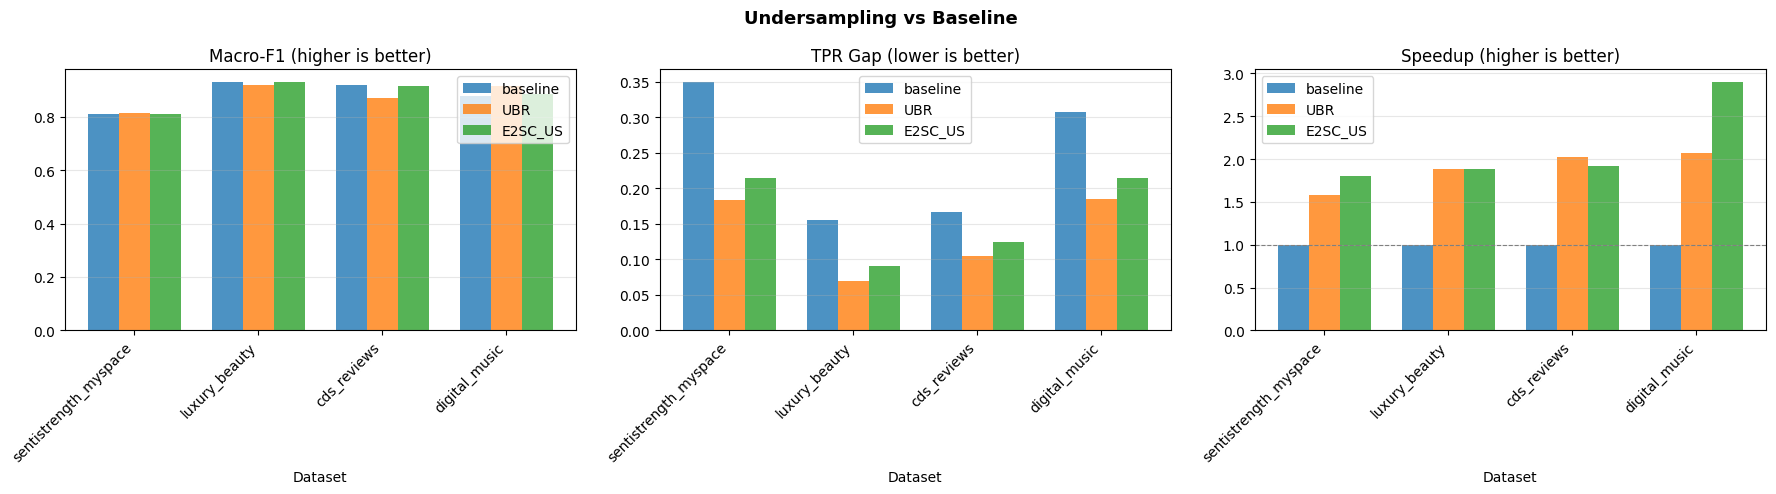

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Undersampling vs Baseline", fontsize=13, fontweight="bold")

df_model = df_results
x = np.arange(len(df_model['dataset'].unique()))
width = 0.25
method_order = ['baseline', 'UBR', 'E2SC_US']

for method_idx, method in enumerate(method_order):
    df_subset = df_model[df_model['method'] == method]
    offset = (method_idx - 1) * width
    axes[0].bar(x + offset, df_subset['macro_f1'].values, width, label=method, alpha=0.8)
    axes[1].bar(x + offset, df_subset['tpr_gap'].values,  width, label=method, alpha=0.8)
    axes[2].bar(x + offset, df_subset['speedup'].values,  width, label=method, alpha=0.8)

titles = [
    'Macro-F1 (higher is better)',
    'TPR Gap (lower is better)',
    'Speedup (higher is better)',
]
for ax, title in zip(axes, titles):
    ax.set_xlabel('Dataset')
    ax.set_xticks(x)
    ax.set_xticklabels(df_model['dataset'].unique(), rotation=45, ha='right')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

axes[2].axhline(1, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

## Conclusion
**Method Effectiveness:**
- **UBR and E2SC_US** show meaningful improvements over **Baseline** in both **Macro-F1 and TPR Gap**
- **E2SC_US** (ensemble-based) generally outperforms simple UBR, especially on highly imbalanced datasets
- **Speedup** values show undersampling methods reduce training time, with E2SC_US achieving ~2x speedup on most datasets

**Fairness-Accuracy Trade-off:**
- Undersampling reduces majority class TPR but improves minority class fairness
- On datasets like sentistrength_myspace and cds_reviews, the HPT Gap reduction is substantial
- On luxury_beauty (less imbalanced), both Macro-F1 and TPR Gap remain strong

As expected, undersampling is a solid strategy for dealing with unbalanced datasets. Comparison with other methods will be shown on 05_conclusion.ipynb.